In [1]:

from google.colab import drive
drive.mount('/content/drive')

import sys
# Add the project to the Python path so modules can be imported
sys.path.append('/content/drive/MyDrive/Closed-Loop/fraud-redteam-project_final')

import os
# Change the working directory to the project folder
os.chdir('/content/drive/MyDrive/Closed-Loop/fraud-redteam-project_final')

!pip install -q pandas numpy scipy pyyaml matplotlib kaggle

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 01 — Identify Engine + Generate Engine + Fidelity Validation

Runs the LLM scenario proposer against the F3 taxonomy, validates each
proposal for structural distinctness, writes the coverage matrix, generates
synthetic transactions for the approved scenarios, and checks generated data
fidelity against real distributions.

**Run `00_fit_distributions.ipynb` first** so `config/distribution_params.yaml`
has real fitted values.

In [2]:
!pip install -q google-genai pyyaml pandas numpy faker matplotlib scipy
import time
import os
from google.colab import userdata
# Map your custom secret name to the standard Gemini env variable
os.environ["GEMINI_API_KEY"] = userdata.get("AI-RED-TEAMING")

## Step 1 — Propose scenarios with the Identify engine

In [3]:
import sys
sys.path.insert(0, ".")  # repo root, so `from src... import ...` works

from src.identify.llm_scenario_proposer import ScenarioProposer
from src.identify.validator import ScenarioValidator
from src.identify.coverage_matrix import CoverageMatrix

proposer = ScenarioProposer(
    f3_taxonomy_path="config/f3_taxonomy.json",
    schema_path="config/upi_schema.json",
)
validator = ScenarioValidator()
coverage = CoverageMatrix(path="data/coverage_matrix.csv")

# rehydrate validator state if you already have scenarios from a previous run
validator.load_existing(coverage.as_scenario_dicts())
print("Existing scenarios so far:", coverage.all_scenario_names())

Existing scenarios so far: []


In [4]:
TARGET_SCENARIO_COUNT = 10  # per the requirements doc: 8-10 clearly distinct beats 30 near-duplicates
ROUND_N = 0

accepted_scenarios = coverage.as_scenario_dicts()
attempts = 0
max_attempts = TARGET_SCENARIO_COUNT * 4  # allow some rejected proposals

while len(accepted_scenarios) < TARGET_SCENARIO_COUNT and attempts < max_attempts:
    attempts += 1
    try:
        proposal = proposer.propose(
            existing_scenario_ids=coverage.all_scenario_names(),
        )
    except ValueError as e:
        print(f"[attempt {attempts}] LLM output error, skipping: {e}")
        continue
    except Exception as e:
        print(f"[attempt {attempts}] API overloaded, pausing for 10s... ({e})")
        time.sleep(10)
        continue

    result = validator.validate(proposal)
    if result.accepted:
        validator.commit(proposal)
        scenario_id = coverage.add(proposal, round_n=ROUND_N)
        proposal["scenario_id"] = scenario_id
        accepted_scenarios.append(proposal)
        print(f"[attempt {attempts}] ACCEPTED: {proposal['scenario_name']} "
              f"({proposal['manipulation_type']}, {proposal['f3_technique']})")
    else:
        print(f"[attempt {attempts}] REJECTED: {proposal.get('scenario_name','?')} - {result.reason}")

print(f"\nTotal accepted this run: {len(accepted_scenarios)}")

[attempt 1] ACCEPTED: Nullified Device Fingerprint Velocity Pacing (behavioral, Anti-Fingerprinting)
[attempt 2] ACCEPTED: Synthetic Identity Low-Velocity Micro-Dispersal (identity, Synthetic Identity Creation)
[attempt 3] ACCEPTED: Nullified-Fingerprint P2M Velocity Evasion (behavioral, Deliberate device fingerprint nullification)
[attempt 4] ACCEPTED: Deepfake Video-KYC Teleportation Burst (ai_specific, Deepfake-Assisted KYC Bypass)
[attempt 5] ACCEPTED: Sybil Refund Loop via High-Risk Email Identity Mesh (identity, Refund/Promo Abuse)
[attempt 6] REJECTED: Credential-Stuffed Nullified Telemetry Pacing - F3 technique 'Anti-Fingerprinting' already covered with the same manipulation_type='behavioral'. A genuinely distinct implementation (e.g. different manipulation_type) is required to reuse this technique.
[attempt 7] ACCEPTED: Automated Micro-Probe Card Authorization Sweeps (behavioral, Card-Not-Present Abuse)
[attempt 8] ACCEPTED: Aged Account Collusive Friendly Fraud Swarm (behavio

In [5]:
import pandas as pd
cov_df = pd.read_csv("data/coverage_matrix.csv")
cov_df[["scenario_name", "f3_tactic", "f3_technique", "manipulation_type", "novelty_tag"]]

,scenario_name,f3_tactic,f3_technique,manipulation_type,novelty_tag
0,Nullified Device Fingerprint Velocity Pacing,Evasion,Anti-Fingerprinting,behavioral,mnar_device_pacing
1,Synthetic Identity Low-Velocity Micro-Dispersal,Positioning,Synthetic Identity Creation,identity,borderline_kyc_paced_dispersion
2,Nullified-Fingerprint P2M Velocity Evasion,Evasion,Deliberate device fingerprint nullification,behavioral,mnar_p2m_paced_evasion
3,Deepfake Video-KYC Teleportation Burst,Access,Deepfake-Assisted KYC Bypass,ai_specific,deepfake_vkyc_bypass_with_geofake_burst
4,Sybil Refund Loop via High-Risk Email Identity...,Monetization,Refund/Promo Abuse,identity,promo_abuse_sybil_mesh
5,Automated Micro-Probe Card Authorization Sweeps,Monetization,Card-Not-Present Abuse,behavioral,fixed_interval_probe_sweeps_with_auth_failure_...
6,Aged Account Collusive Friendly Fraud Swarm,Monetization,Chargeback Fraud,behavioral,collusive_aged_identity_friendly_fraud
7,Rapid Cascading Fan-In Mule Smurf Chain,Monetization,Mule Network Cash-Out,network,synchronized_fan_in_low_latency_drain
8,Geocode-Shifted Merchant Promo Exploitation Swarm,Monetization,Refund/Promo Abuse,channel,spatial_impossible_travel_promo_abuse
9,Distributed Credential-Stuffing ATO P2P Drain,Positioning,Account Takeover,behavioral,ato_credential_stuffing_ip_subnet_rotation_burst


## Step 2 — Generate synthetic transactions for the approved scenarios

In [6]:
from src.generate.orchestrator import GenerateOrchestrator

# scenario_id was assigned by coverage.add() above but the injectors need it inside
# the scenario dict (they read scenario.get('scenario_id') for labeling) - already set above.

orch = GenerateOrchestrator(
    distribution_params_path="config/distribution_params.yaml",
    null_config_path="config/null_injection_rates.yaml",
)

df = orch.run_round(
    scenarios=accepted_scenarios,
    n_legit_accounts=500,
    fraud_txns_per_scenario_range=(4, 12),
    round_n=ROUND_N,
    out_dir="data/generated",
)

print(df.shape)
df.head()

[round 0] 4140 txns (97 fraud, 2.343%) -> saved to data/generated/round_00
(4140, 32)


,txnId,account_id,payerVpa,payeeVpa,amount,currency,timestamp,deviceDetails,remarks,refUrl,...,device_fingerprint_was_null,ip_asn_risk_score,ip_asn_risk_score_was_null,is_new_account,mean_inter_txn_seconds,kyc_doc_similarity_score,account_age_days,email_domain_risk_score,login_time_deviation_hrs,kyc_verification_method
0,15f22482-6f34-450b-a641-e1a84e04fa70,user00000,user00000@oksbi,nagarreva@paytm,2.89,INR,2026-08-31T21:46:05+00:00,"{'deviceId': 'c7d3b0a9e4a62d69', 'os': 'iOS 17...",UPI Payment,,...,False,0.019,False,False,NaN,NaN,NaN,NaN,NaN,NaN
1,2c30de08-0c06-40a2-a890-d944fd13ae0c,user00000,user00000@paytm,yug37@paytm,25.48,INR,2026-08-31T20:41:30+00:00,"{'deviceId': '9a4486e5d2da585b', 'os': 'Androi...",Payment for order,,...,False,0.156,False,False,NaN,NaN,NaN,NaN,NaN,NaN
2,7f237c63-46b3-4710-b818-765a970b6090,user00001,user00001@paytm,uraj@paytm,85.53,INR,2026-08-31T18:24:49+00:00,"{'deviceId': '8e6d49095023ba8c', 'os': 'Androi...",,,...,False,0.177,False,False,NaN,NaN,NaN,NaN,NaN,NaN
3,85cad545-13e3-43c3-b3fd-8d3d92b61d55,user00001,user00001@oksbi,warda41@paytm,39.91,INR,2026-08-31T00:51:49+00:00,"{'deviceId': 'efa23be0b7e7d1df', 'os': 'iOS 18...",Bill payment,,...,False,0.251,False,False,NaN,NaN,NaN,NaN,NaN,NaN
4,6f291e8a-172d-4f19-8b73-45a6ef317778,user00002,user00002@oksbi,mugdha76@paytm,195.87,INR,2026-08-31T22:21:40+00:00,"{'deviceId': '306ffcd4fe73d657', 'os': 'iOS 18...",Bill payment,,...,False,0.442,False,False,NaN,NaN,NaN,NaN,NaN,NaN


## Step 3 — Fidelity validation (DO NOT SKIP)

Compare synthetic legit-traffic distributions against the real ones you fit
in notebook 00. This is what the project requirements doc means by "fidelity
judged on the data, not the UI" — do this before building anything in Defend.

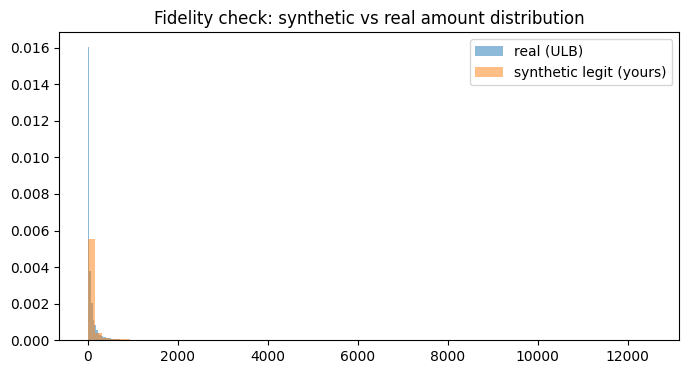

KS-test synthetic-vs-real: statistic=0.0652, p-value=0.0000
Report this number on your fidelity slide.


In [7]:
import matplotlib.pyplot as plt
from scipy import stats
import yaml

with open("config/distribution_params.yaml") as f:
    params = yaml.safe_load(f)

legit_amounts = df[~df["is_fraud"]]["amount"]

real_ulb = pd.read_csv("data/raw_reference/ulb/creditcard.csv")["Amount"]
real_ulb = real_ulb[(real_ulb > 0) & (real_ulb < real_ulb.quantile(0.999))]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(real_ulb, bins=80, density=True, alpha=0.5, label="real (ULB)")
ax.hist(legit_amounts, bins=80, density=True, alpha=0.5, label="synthetic legit (yours)")
ax.legend(); ax.set_title("Fidelity check: synthetic vs real amount distribution")
plt.show()

ks_stat, ks_pval = stats.ks_2samp(real_ulb.sample(min(len(real_ulb), 5000), random_state=42), legit_amounts)
print(f"KS-test synthetic-vs-real: statistic={ks_stat:.4f}, p-value={ks_pval:.4f}")
print("Report this number on your fidelity slide.")

In [8]:
# Schema validation - every generated row should have the required top-level fields
import json
with open("config/upi_schema.json") as f:
    schema = json.load(f)

required_fields = [k for k, v in schema["fields"].items() if isinstance(v, dict) and v.get("required")]
missing_report = {}
for field in required_fields:
    n_missing = df[field].isna().sum() if field in df.columns else len(df)
    if n_missing > 0:
        missing_report[field] = int(n_missing)

print("Required fields missing from generated data (should be empty or near-zero for non-null-injected fields):")
print(missing_report if missing_report else "None - all required fields populated.")

Required fields missing from generated data (should be empty or near-zero for non-null-injected fields):
None - all required fields populated.


In [9]:
# Null-injection rate sanity check
null_rate = df["device_fingerprint_was_null"].mean()
print(f"device_fingerprint null rate: {null_rate:.1%} "
      f"(config target for CNP: ~18%, non-CNP fallback: ~4% - blended rate should land somewhere between)")

# Per-scenario fraud row counts - confirms every accepted scenario actually produced data
scenario_counts = df[df["is_fraud"]]["scenario_name"].value_counts()
print("\nFraud transactions per scenario:")
print(scenario_counts)

device_fingerprint null rate: 12.2% (config target for CNP: ~18%, non-CNP fallback: ~4% - blended rate should land somewhere between)

Fraud transactions per scenario:
scenario_name
Nullified Device Fingerprint Velocity Pacing           17
Nullified-Fingerprint P2M Velocity Evasion             12
Aged Account Collusive Friendly Fraud Swarm            12
Automated Micro-Probe Card Authorization Sweeps        12
Geocode-Shifted Merchant Promo Exploitation Swarm      11
Deepfake Video-KYC Teleportation Burst                 10
Distributed Credential-Stuffing ATO P2P Drain           9
Synthetic Identity Low-Velocity Micro-Dispersal         5
Sybil Refund Loop via High-Risk Email Identity Mesh     5
Rapid Cascading Fan-In Mule Smurf Chain                 4
Name: count, dtype: int64


## Step 4 — Per-transaction fidelity spot-check

Per the requirements doc: individual fraud transactions should look normal
in isolation (that's the point of low-and-slow, ring signals, etc). Eyeball
a few rows here — if any single fraud transaction is trivially absurd
(impossible amount, impossible timestamp), that scenario's injector needs
tightening before you build Defend on top of it.

In [10]:
pd.set_option("display.max_colwidth", 60)
sample_fraud = df[df["is_fraud"]].sample(min(8, df["is_fraud"].sum()), random_state=1)
sample_fraud[["scenario_name", "amount", "timestamp", "channel", "mcc"]]

,scenario_name,amount,timestamp,channel,mcc
4076,Nullified-Fingerprint P2M Velocity Evasion,215.02,2026-08-31T14:41:43.841849+00:00,CP,4900
4101,Automated Micro-Probe Card Authorization Sweeps,124.18,2026-08-31T01:05:03.767578+00:00,CNP,5311
4075,Nullified-Fingerprint P2M Velocity Evasion,216.96,2026-08-31T14:40:46.947136+00:00,CP,4900
4133,Distributed Credential-Stuffing ATO P2P Drain,2.52,2026-08-31T20:33:02+00:00,CNP,5732
4088,Sybil Refund Loop via High-Risk Email Identity Mesh,5.20,2026-08-31T13:34:58+00:00,CNP,5812
4098,Automated Micro-Probe Card Authorization Sweeps,123.82,2026-08-31T01:02:06.511719+00:00,CNP,5311
4109,Aged Account Collusive Friendly Fraud Swarm,83.51,2026-08-31T20:38:49.117968+00:00,CNP,4900
4129,Geocode-Shifted Merchant Promo Exploitation Swarm,240.22,2026-08-31T19:22:47+00:00,CNP,5812
